```
# Deep Quantum Neural Network (DQNN) for FashionMNIST using PennyLane + PyTorch
# Install:
# pip install torch torchvision pennylane tqdm


Classical Neural Network
        ↓
Variational Quantum Circuit (VQC)
        ↓
Classical Classifier
```


---
## Overall Data Flow
```
28×28 Image
      │
      ▼
Flatten (784)
      │
      ▼
Classical Dense Network
784 → 256 → 128 → NUM_QUBITS
      │
      ▼
Quantum Circuit
AngleEmbedding
      │
StronglyEntanglingLayers
      │
Expectation Values (<Zi>)
      │
      ▼
Dense Classifier
NUM_QUBITS → 64 → 10
      │
      ▼
Softmax (via CrossEntropyLoss during training)
      │
      ▼
Predicted Digit (0–9)
```

In [1]:
!pip install pennylane torch torchvision matplotlib scikit-learn seaborn -q  

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 73.0 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import pennylane as qml
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import io
import torch
from PIL import Image, ImageOps
import torchvision.transforms as transforms
from ipywidgets import FileUpload, Button, Output, VBox, Label
from IPython.display import display
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import pennylane as qml
# ============================================================
# SIMAM-Enhanced Hybrid Quantum-Classical Neural Network
# FashionMNIST Classification
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import pennylane as qml

from tqdm.auto import tqdm

from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

print("🔥Imports Loaded!!!")

🔥Imports Loaded!!!


```
MNIST:
1 × 28 × 28 = 784
        ↓
SIMAM
        ↓
784 → 256 → 128 → 8 qubits

CIFAR-10:
3 × 32 × 32 = 3072
          ↓
       SIMAM
          ↓
3072 → 256 → 128 → 8 qubits
```

Using Seed: 42
Using device: cpu


100%|██████████| 170M/170M [29:27<00:00, 96.5kB/s]



Training class distribution:
Counter({np.int64(4): 4529, np.int64(3): 4529, np.int64(0): 4512, np.int64(7): 4500, np.int64(9): 4499, np.int64(8): 4496, np.int64(6): 4493, np.int64(1): 4488, np.int64(5): 4486, np.int64(2): 4468})

Testing class distribution:
Counter({np.int64(3): 1000, np.int64(8): 1000, np.int64(0): 1000, np.int64(6): 1000, np.int64(1): 1000, np.int64(9): 1000, np.int64(5): 1000, np.int64(7): 1000, np.int64(4): 1000, np.int64(2): 1000})

Class Weights:
Class 0: 0.9973
Class 1: 1.0027
Class 2: 1.0072
Class 3: 0.9936
Class 4: 0.9936
Class 5: 1.0031
Class 6: 1.0016
Class 7: 1.0000
Class 8: 1.0009
Class 9: 1.0002


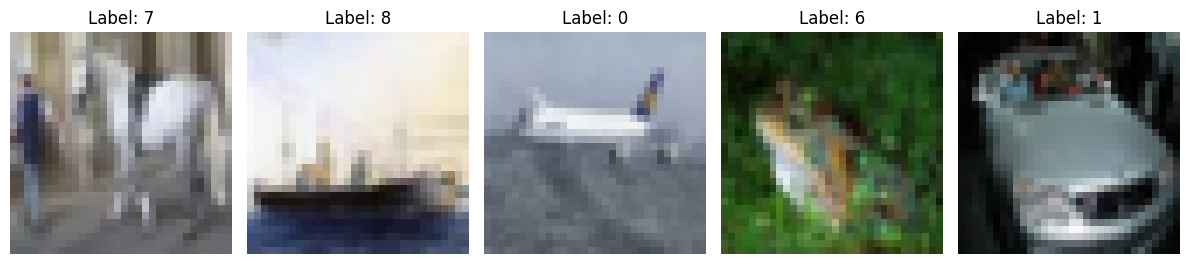

Number of Classes: 10

MODEL ARCHITECTURE
DeepQNN(
  (classical): Sequential(
    (0): Linear(in_features=3072, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

Model Parameters
----------------------------
Total Parameters     : 821,986
Trainable Parameters : 821,986
Quantum Parameters   : 144
Number of Qubits     : 8
Quantum Layers       : 6
SIMAM Parameters     : 0

Starting Training...



Epoch 1/25 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [01/25] | Train Loss: 2.1989 | Train Acc: 15.51% | Val Loss: 2.1518 | Val Acc: 18.10%


Epoch 2/25 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

...

Epoch 25/25 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [25/25] | Train Loss: 1.4212 | Train Acc: 47.68% | Val Loss: 1.6960 | Val Acc: 40.60%


Testing:   0%|          | 0/157 [00:00<?, ?it/s]


Final Test Accuracy: 41.04%

Sample Prediction
-----------------
True Label     : 3
Predicted Label: 6


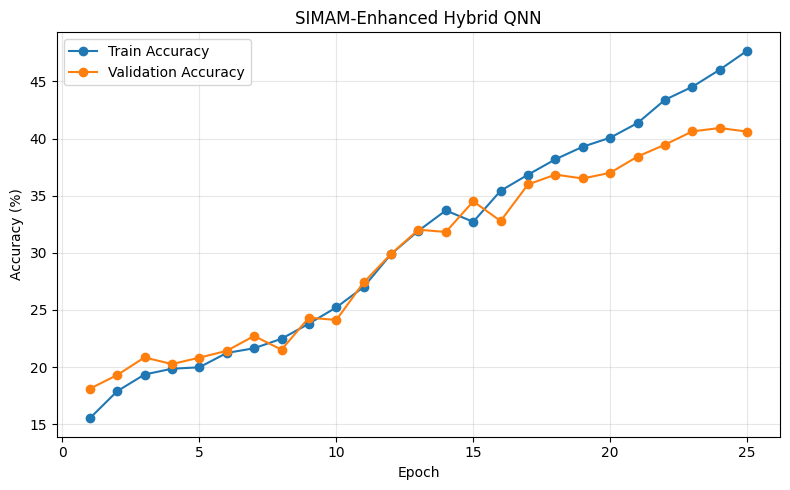

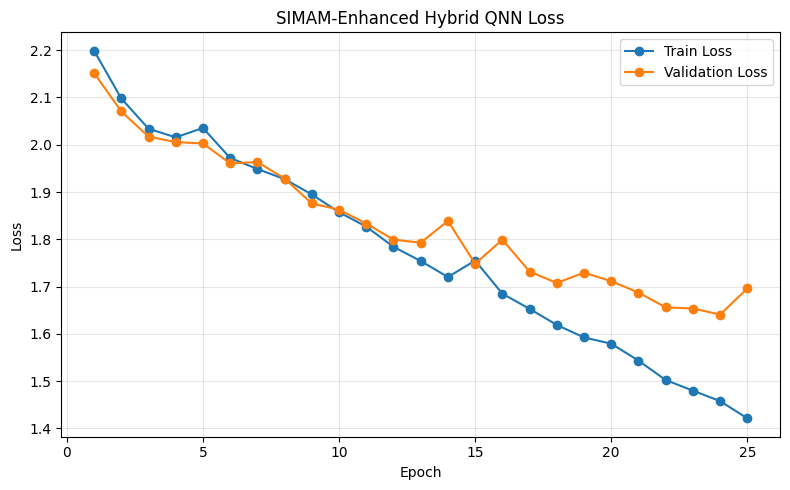

In [3]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using Seed: {SEED}")


# ============================================================
# Hyperparameters
# ============================================================

BATCH_SIZE = 64
EPOCHS = 25
LR = 0.001

NUM_QUBITS = 8
NUM_LAYERS = 6

SIMAM_E_LAMBDA = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")



# ============================================================
# Dataset
# ============================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    ),
])

full_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# Train / Validation Split
# ============================================================

val_fraction = 0.1

val_size = int(
    len(full_train_dataset) * val_fraction
)

train_size = (
    len(full_train_dataset) - val_size
)


train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Class Distribution
# ============================================================

# train_labels = full_train_dataset.targets.numpy()

# ============================================================
# Class Distribution
# ============================================================

train_labels = np.array(
    full_train_dataset.targets
)[train_dataset.indices]

test_labels = np.array(
    test_dataset.targets
)

print("\nTraining class distribution:")
print(Counter(train_labels))

print("\nTesting class distribution:")
print(Counter(test_labels))

# ============================================================
# Class Weights
# ============================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

print("\nClass Weights:")

for i, w in enumerate(class_weights):
    print(
        f"Class {i}: {w.item():.4f}"
    )


# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization for visualization
    mean = np.array(
        [0.4914, 0.4822, 0.4465]
    )
    
    std = np.array(
        [0.2470, 0.2435, 0.2616]
    )
    
    img = image.permute(
        1, 2, 0
    ).numpy()
    
    img = (
        img * std + mean
    )
    
    img = np.clip(
        img,
        0,
        1
    )
    
    ax.imshow(img)

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()

# ============================================================
# Number of Classes — Automatically Detected
# ============================================================
NUM_CLASSES = len(
    np.unique(
        np.array(full_train_dataset.targets)
    )
)
print(f"Number of Classes: {NUM_CLASSES}")


# ============================================================
# SIMAM
# Simple Attention Module
# ============================================================

class SIMAM(nn.Module):

    def __init__(
        self,
        e_lambda=1e-4
    ):

        super().__init__()

        self.e_lambda = e_lambda


    def forward(self, x):

        # ----------------------------------------------------
        # Expected input:
        #
        # x = [Batch, Channels, Height, Width]
        #
        # FashionMNIST:
        #
        # x = [B, 1, 28, 28]
        # ----------------------------------------------------

        b, c, h, w = x.size()


        # ----------------------------------------------------
        # Number of spatial locations minus one
        # ----------------------------------------------------

        n = h * w - 1


        # ----------------------------------------------------
        # Spatial mean
        # ----------------------------------------------------

        mean = x.mean(
            dim=(2, 3),
            keepdim=True
        )


        # ----------------------------------------------------
        # Squared deviation from mean
        # ----------------------------------------------------

        squared_diff = (
            x - mean
        ) ** 2


        # ----------------------------------------------------
        # Spatial variance
        # ----------------------------------------------------

        variance = (
            squared_diff.sum(
                dim=(2, 3),
                keepdim=True
            ) / n
        )


        # ----------------------------------------------------
        # SIMAM Energy
        # ----------------------------------------------------

        energy = (
            squared_diff
            /
            (
                4
                * (
                    variance
                    + self.e_lambda
                )
            )
        ) + 0.5


        # ----------------------------------------------------
        # Attention weights
        # ----------------------------------------------------

        attention = torch.sigmoid(
            1.0 / energy
        )


        # ----------------------------------------------------
        # Re-weight feature map
        # ----------------------------------------------------

        return x * attention


# ============================================================
# Quantum Device
# ============================================================

dev = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


# ============================================================
# Quantum Circuit
# ============================================================

@qml.qnode(
    dev,
    interface="torch",
    diff_method="backprop"
)

def quantum_circuit(
    inputs,
    weights
):

    # --------------------------------------------------------
    # Quantum Data Encoding
    # --------------------------------------------------------

    qml.AngleEmbedding(
        inputs,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Variational Quantum Circuit
    # --------------------------------------------------------

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Pauli-Z Measurements
    # --------------------------------------------------------

    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(NUM_QUBITS)
    ]


# ============================================================
# Quantum Parameter Shape
# ============================================================

weight_shapes = {

    "weights": (
        NUM_LAYERS,
        NUM_QUBITS,
        3
    )

}


# ============================================================
# Quantum Layer
# ============================================================

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)


# ============================================================
# Deep Hybrid QNN
# ============================================================

# class DeepQNN(nn.Module):

#     def __init__(self, num_classes):

#         super().__init__()


#         # ====================================================
#         # 1. SIMAM Attention
#         # ====================================================

#         self.simam = SIMAM(
#             e_lambda=SIMAM_E_LAMBDA
#         )


#         # ====================================================
#         # 2. Classical Feature Extractor
#         # ====================================================

#         self.classical = nn.Sequential(

#             # 784 → 256
#             # nn.Linear(
#             #     784,
#             #     256
#             # ),
#             nn.Linear(3072, 256),
#             nn.ReLU(),


#             # 256 → 128
#             nn.Linear(
#                 256,
#                 128
#             ),

#             nn.ReLU(),


        #     # 128 → NUM_QUBITS
        #     nn.Linear(
        #         128,
        #         NUM_QUBITS
        #     )

        # )


        # # ====================================================
        # # 3. Quantum Neural Network
        # # ====================================================

        # self.quantum = quantum_layer


        # # ====================================================
        # # 4. Classical Classifier
        # # ====================================================

        # self.classifier = nn.Sequential(

        #     # NUM_QUBITS → 64
        #     nn.Linear(
        #         NUM_QUBITS,
        #         64
        #     ),

        #     nn.ReLU(),


        #     # 64 → 10
        #     nn.Linear(
        #         64,
        #         num_classes
        #     )
        # )


    # # ========================================================
    # # Forward Pass
    # # ========================================================

    # def forward(self, x):


    #     # ====================================================
    #     # STEP 1 — Input
    #     # ====================================================
    #     #
    #     # x:
    #     #
    #     # [B, 1, 28, 28]
    #     #
    #     # ====================================================


    #     # ====================================================
    #     # STEP 2 — SIMAM
    #     # ====================================================

    #     x = self.simam(x)


    #     # ====================================================
    #     # STEP 3 — Flatten
    #     # ====================================================
    #     #
    #     # [B, 1, 28, 28]
    #     #
    #     #        ↓
    #     #
    #     # [B, 784]
    #     #
    #     # ====================================================

    #     x = x.flatten(
    #         start_dim=1
    #     )


        # # ====================================================
        # # STEP 4 — Classical Feature Extraction
        # # ====================================================
        # #
        # # 784 → 256 → 128 → NUM_QUBITS
        # #
        # # ====================================================

        # x = self.classical(x)


        # # ====================================================
        # # STEP 5 — Bound Quantum Angles
        # # ====================================================
        # #
        # # tanh:
        # #
        # # [-∞, +∞] → [-1, +1]
        # #
        # # × π:
        # #
        # # [-1, +1] → [-π, +π]
        # #
        # # ====================================================

        # x = torch.tanh(x) * np.pi


        # # ====================================================
        # # STEP 6 — Quantum Circuit
        # # ====================================================

        # quantum_device = x.device


        # # default.qubit runs on CPU
        # x = self.quantum(
        #     x.cpu()
        # )


        # # Move quantum output back
        # # to original device

        # x = x.to(
        #     quantum_device
        # )


        # # ====================================================
        # # STEP 7 — Classical Classifier
        # # ====================================================
        # #
        # # NUM_QUBITS → 64 → 10
        # #
        # # ====================================================

        # x = self.classifier(x)


        # return x

class DeepQNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        # ====================================================
        # 1. Classical Feature Extractor
        # ====================================================

        self.classical = nn.Sequential(

            # 3072 → 256
            nn.Linear(3072, 256),
            nn.ReLU(),

            # 256 → 128
            nn.Linear(256, 128),
            nn.ReLU(),

            # 128 → 8 qubits
            nn.Linear(128, NUM_QUBITS)
        )

        # ====================================================
        # 2. Quantum Neural Network
        # ====================================================

        self.quantum = quantum_layer

        # ====================================================
        # 3. Classical Classifier
        # ====================================================

        self.classifier = nn.Sequential(

            # 8 → 64
            nn.Linear(NUM_QUBITS, 64),
            nn.ReLU(),

            # 64 → 10
            nn.Linear(64, num_classes)
        )


    def forward(self, x):

            # ====================================================
            # STEP 1 — Flatten CIFAR-10 Image
            # ====================================================
            # [B, 3, 32, 32]
            #      ↓
            # [B, 3072]
            # ====================================================
        
            x = x.flatten(start_dim=1)
        
            # ====================================================
            # STEP 2 — Classical Feature Extraction
            # ====================================================
            # 3072 → 256 → 128 → 8
            # ====================================================
        
            x = self.classical(x)
        
            # ====================================================
            # STEP 3 — Bound Quantum Angles
            # ====================================================
        
            x = torch.tanh(x) * np.pi
        
            # ====================================================
            # STEP 4 — Quantum Circuit
            # ====================================================
        
            quantum_device = x.device
        
            x = self.quantum(x.cpu())
        
            # Move quantum output back
            x = x.to(quantum_device)
        
            # ====================================================
            # STEP 5 — Classical Classifier
            # ====================================================
            # 8 → 64 → 10
            # ====================================================
        
            x = self.classifier(x)
        
            return x

# ============================================================
# Create Model
# ============================================================

model = DeepQNN(
    num_classes=NUM_CLASSES
).to(DEVICE)


# ============================================================
# Model Summary
# ============================================================

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

print(model)


# ============================================================
# Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


print("\nModel Parameters")
print("----------------------------")

print(
    f"Total Parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params:,}"
)

print(
    f"Quantum Parameters   : "
    f"{quantum_params:,}"
)

print(
    f"Number of Qubits     : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum Layers       : "
    f"{NUM_LAYERS}"
)

print(
    f"SIMAM Parameters     : 0"
)

print("=" * 60)


# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# Training
# ============================================================

print("\nStarting Training...\n")


# ============================================================
# History
# ============================================================

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []


# ============================================================
# Epoch Loop
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()


    train_loss = 0.0

    train_correct = 0

    train_total = 0


    train_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Train]"
        ),
        leave=False
    )


    for step, (
        images,
        labels
    ) in enumerate(
        train_bar,
        start=1
    ):


        # ----------------------------------------------------
        # Move data to device
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # Update parameters
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Accumulate loss
        # ----------------------------------------------------

        train_loss += loss.item()


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        _, predicted = torch.max(
            outputs,
            1
        )


        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        train_bar.set_postfix(

            Loss=(
                f"{train_loss / step:.4f}"
            ),

            Acc=(
                f"{100 * train_correct / train_total:.2f}%"
            )

        )


    # ========================================================
    # Epoch Training Metrics
    # ========================================================

    train_loss /= len(
        train_loader
    )

    train_acc = (
        100
        * train_correct
        / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_loss = 0.0

    val_correct = 0

    val_total = 0


    val_bar = tqdm(
        val_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Val]"
        ),
        leave=False
    )


    with torch.no_grad():

        for step, (
            images,
            labels
        ) in enumerate(
            val_bar,
            start=1
        ):


            # ------------------------------------------------
            # Move data
            # ------------------------------------------------

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # Validation loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            val_loss += loss.item()


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            _, predicted = torch.max(
                outputs,
                1
            )


            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            # ------------------------------------------------
            # Progress bar
            # ------------------------------------------------

            val_bar.set_postfix(

                Loss=(
                    f"{val_loss / step:.4f}"
                ),

                Acc=(
                    f"{100 * val_correct / val_total:.2f}%"
                )

            )


    # ========================================================
    # Epoch Validation Metrics
    # ========================================================

    val_loss /= len(
        val_loader
    )

    val_acc = (
        100
        * val_correct
        / val_total
    )


    # ========================================================
    # Store History
    # ========================================================

    train_loss_history.append(
        train_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_loss_history.append(
        val_loss
    )

    val_acc_history.append(
        val_acc
    )


    # ========================================================
    # Epoch Summary
    # ========================================================

    print(

        f"Epoch "
        f"[{epoch + 1:02d}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Train Acc: "
        f"{train_acc:.2f}% | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val Acc: "
        f"{val_acc:.2f}%"

    )


# ============================================================
# FINAL TESTING
# ============================================================

model.eval()


correct = 0

total = 0


test_bar = tqdm(
    test_loader,
    desc="Testing"
)


with torch.no_grad():

    for images, labels in test_bar:


        # ----------------------------------------------------
        # Move data
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        _, predicted = outputs.max(
            1
        )


        # ----------------------------------------------------
        # Accuracy
        # ----------------------------------------------------

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


        test_bar.set_postfix({

            "Acc":
                f"{100 * correct / total:.2f}%"

        })


# ============================================================
# Final Test Accuracy
# ============================================================

final_test_accuracy = (
    100
    * correct
    / total
)


print(
    f"\nFinal Test Accuracy: "
    f"{final_test_accuracy:.2f}%"
)


# ============================================================
# Predict One Test Sample
# ============================================================

image, label = test_dataset[0]


model.eval()


with torch.no_grad():

    prediction = model(
        image.unsqueeze(0).to(
            DEVICE
        )
    )

    predicted = (
        prediction
        .argmax(dim=1)
        .item()
    )


print("\nSample Prediction")
print("-----------------")

print(
    "True Label     :",
    label
)

print(
    "Predicted Label:",
    predicted
)


# ============================================================
# Plot Training / Validation Accuracy
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_acc_history,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_acc_history,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "SIMAM-Enhanced Hybrid QNN"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_accuracy.png",
    dpi=150
)

plt.show()


# ============================================================
# Plot Training / Validation Loss
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_loss_history,
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_loss_history,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "SIMAM-Enhanced Hybrid QNN Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_loss.png",
    dpi=150
)

plt.show()

Using Seed: 32
Using device: cpu

Training class distribution:
Counter({np.int64(2): 4549, np.int64(7): 4537, np.int64(0): 4513, np.int64(1): 4502, np.int64(3): 4499, np.int64(4): 4494, np.int64(6): 4481, np.int64(8): 4480, np.int64(9): 4474, np.int64(5): 4471})

Testing class distribution:
Counter({np.int64(3): 1000, np.int64(8): 1000, np.int64(0): 1000, np.int64(6): 1000, np.int64(1): 1000, np.int64(9): 1000, np.int64(5): 1000, np.int64(7): 1000, np.int64(4): 1000, np.int64(2): 1000})

Class Weights:
Class 0: 0.9971
Class 1: 0.9996
Class 2: 0.9892
Class 3: 1.0002
Class 4: 1.0013
Class 5: 1.0065
Class 6: 1.0042
Class 7: 0.9918
Class 8: 1.0045
Class 9: 1.0058


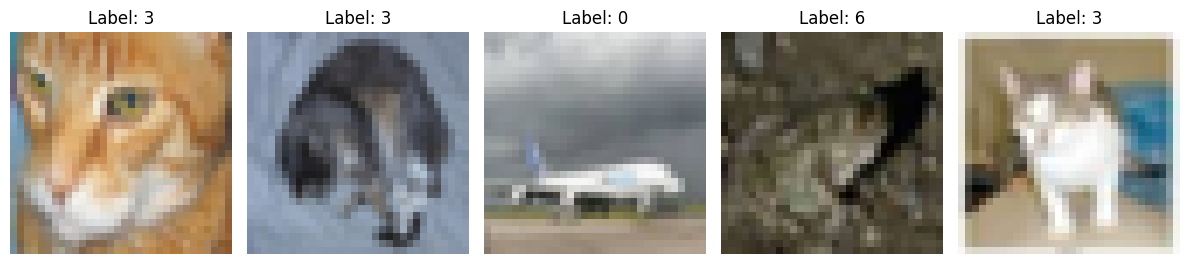

Number of Classes: 10

MODEL ARCHITECTURE
DeepQNN(
  (classical): Sequential(
    (0): Linear(in_features=3072, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

Model Parameters
----------------------------
Total Parameters     : 821,986
Trainable Parameters : 821,986
Quantum Parameters   : 144
Number of Qubits     : 8
Quantum Layers       : 6
SIMAM Parameters     : 0

Starting Training...



Epoch 1/25 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [01/25] | Train Loss: 2.2288 | Train Acc: 14.33% | Val Loss: 2.1305 | Val Acc: 17.10%


Epoch 2/25 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

...

Epoch 25/25 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [25/25] | Train Loss: 1.1604 | Train Acc: 56.80% | Val Loss: 1.6358 | Val Acc: 43.84%


Testing:   0%|          | 0/157 [00:00<?, ?it/s]


Final Test Accuracy: 44.14%

Sample Prediction
-----------------
True Label     : 3
Predicted Label: 3


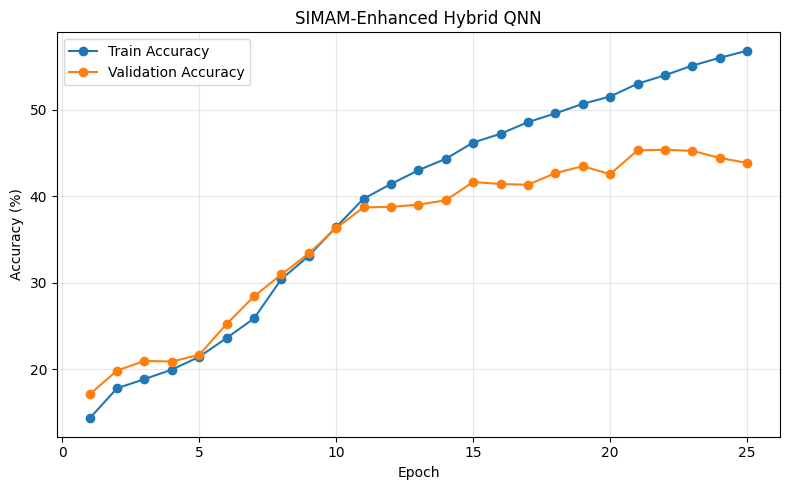

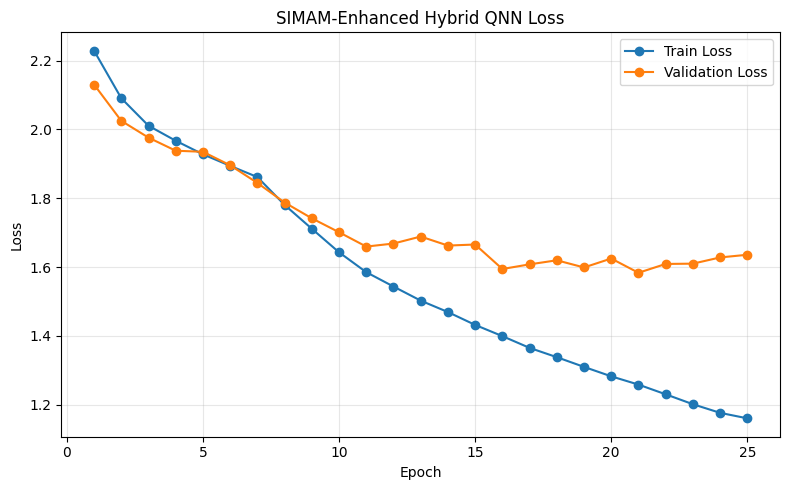

In [4]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 32

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using Seed: {SEED}")


# ============================================================
# Hyperparameters
# ============================================================

BATCH_SIZE = 64
EPOCHS = 25
LR = 0.001

NUM_QUBITS = 8
NUM_LAYERS = 6

SIMAM_E_LAMBDA = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")



# ============================================================
# Dataset
# ============================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    ),
])

full_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# Train / Validation Split
# ============================================================

val_fraction = 0.1

val_size = int(
    len(full_train_dataset) * val_fraction
)

train_size = (
    len(full_train_dataset) - val_size
)


train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Class Distribution
# ============================================================

# train_labels = full_train_dataset.targets.numpy()

# ============================================================
# Class Distribution
# ============================================================

train_labels = np.array(
    full_train_dataset.targets
)[train_dataset.indices]

test_labels = np.array(
    test_dataset.targets
)

print("\nTraining class distribution:")
print(Counter(train_labels))

print("\nTesting class distribution:")
print(Counter(test_labels))

# ============================================================
# Class Weights
# ============================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

print("\nClass Weights:")

for i, w in enumerate(class_weights):
    print(
        f"Class {i}: {w.item():.4f}"
    )


# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization for visualization
    mean = np.array(
        [0.4914, 0.4822, 0.4465]
    )
    
    std = np.array(
        [0.2470, 0.2435, 0.2616]
    )
    
    img = image.permute(
        1, 2, 0
    ).numpy()
    
    img = (
        img * std + mean
    )
    
    img = np.clip(
        img,
        0,
        1
    )
    
    ax.imshow(img)

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()

# ============================================================
# Number of Classes — Automatically Detected
# ============================================================
NUM_CLASSES = len(
    np.unique(
        np.array(full_train_dataset.targets)
    )
)
print(f"Number of Classes: {NUM_CLASSES}")


# ============================================================
# SIMAM
# Simple Attention Module
# ============================================================

class SIMAM(nn.Module):

    def __init__(
        self,
        e_lambda=1e-4
    ):

        super().__init__()

        self.e_lambda = e_lambda


    def forward(self, x):

        # ----------------------------------------------------
        # Expected input:
        #
        # x = [Batch, Channels, Height, Width]
        #
        # FashionMNIST:
        #
        # x = [B, 1, 28, 28]
        # ----------------------------------------------------

        b, c, h, w = x.size()


        # ----------------------------------------------------
        # Number of spatial locations minus one
        # ----------------------------------------------------

        n = h * w - 1


        # ----------------------------------------------------
        # Spatial mean
        # ----------------------------------------------------

        mean = x.mean(
            dim=(2, 3),
            keepdim=True
        )


        # ----------------------------------------------------
        # Squared deviation from mean
        # ----------------------------------------------------

        squared_diff = (
            x - mean
        ) ** 2


        # ----------------------------------------------------
        # Spatial variance
        # ----------------------------------------------------

        variance = (
            squared_diff.sum(
                dim=(2, 3),
                keepdim=True
            ) / n
        )


        # ----------------------------------------------------
        # SIMAM Energy
        # ----------------------------------------------------

        energy = (
            squared_diff
            /
            (
                4
                * (
                    variance
                    + self.e_lambda
                )
            )
        ) + 0.5


        # ----------------------------------------------------
        # Attention weights
        # ----------------------------------------------------

        attention = torch.sigmoid(
            1.0 / energy
        )


        # ----------------------------------------------------
        # Re-weight feature map
        # ----------------------------------------------------

        return x * attention


# ============================================================
# Quantum Device
# ============================================================

dev = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


# ============================================================
# Quantum Circuit
# ============================================================

@qml.qnode(
    dev,
    interface="torch",
    diff_method="backprop"
)

def quantum_circuit(
    inputs,
    weights
):

    # --------------------------------------------------------
    # Quantum Data Encoding
    # --------------------------------------------------------

    qml.AngleEmbedding(
        inputs,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Variational Quantum Circuit
    # --------------------------------------------------------

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Pauli-Z Measurements
    # --------------------------------------------------------

    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(NUM_QUBITS)
    ]


# ============================================================
# Quantum Parameter Shape
# ============================================================

weight_shapes = {

    "weights": (
        NUM_LAYERS,
        NUM_QUBITS,
        3
    )

}


# ============================================================
# Quantum Layer
# ============================================================

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)


# ============================================================
# Deep Hybrid QNN
# ============================================================

# class DeepQNN(nn.Module):

#     def __init__(self, num_classes):

#         super().__init__()


#         # ====================================================
#         # 1. SIMAM Attention
#         # ====================================================

#         self.simam = SIMAM(
#             e_lambda=SIMAM_E_LAMBDA
#         )


#         # ====================================================
#         # 2. Classical Feature Extractor
#         # ====================================================

#         self.classical = nn.Sequential(

#             # 784 → 256
#             # nn.Linear(
#             #     784,
#             #     256
#             # ),
#             nn.Linear(3072, 256),
#             nn.ReLU(),


#             # 256 → 128
#             nn.Linear(
#                 256,
#                 128
#             ),

#             nn.ReLU(),


        #     # 128 → NUM_QUBITS
        #     nn.Linear(
        #         128,
        #         NUM_QUBITS
        #     )

        # )


        # # ====================================================
        # # 3. Quantum Neural Network
        # # ====================================================

        # self.quantum = quantum_layer


        # # ====================================================
        # # 4. Classical Classifier
        # # ====================================================

        # self.classifier = nn.Sequential(

        #     # NUM_QUBITS → 64
        #     nn.Linear(
        #         NUM_QUBITS,
        #         64
        #     ),

        #     nn.ReLU(),


        #     # 64 → 10
        #     nn.Linear(
        #         64,
        #         num_classes
        #     )
        # )


    # # ========================================================
    # # Forward Pass
    # # ========================================================

    # def forward(self, x):


    #     # ====================================================
    #     # STEP 1 — Input
    #     # ====================================================
    #     #
    #     # x:
    #     #
    #     # [B, 1, 28, 28]
    #     #
    #     # ====================================================


    #     # ====================================================
    #     # STEP 2 — SIMAM
    #     # ====================================================

    #     x = self.simam(x)


    #     # ====================================================
    #     # STEP 3 — Flatten
    #     # ====================================================
    #     #
    #     # [B, 1, 28, 28]
    #     #
    #     #        ↓
    #     #
    #     # [B, 784]
    #     #
    #     # ====================================================

    #     x = x.flatten(
    #         start_dim=1
    #     )


        # # ====================================================
        # # STEP 4 — Classical Feature Extraction
        # # ====================================================
        # #
        # # 784 → 256 → 128 → NUM_QUBITS
        # #
        # # ====================================================

        # x = self.classical(x)


        # # ====================================================
        # # STEP 5 — Bound Quantum Angles
        # # ====================================================
        # #
        # # tanh:
        # #
        # # [-∞, +∞] → [-1, +1]
        # #
        # # × π:
        # #
        # # [-1, +1] → [-π, +π]
        # #
        # # ====================================================

        # x = torch.tanh(x) * np.pi


        # # ====================================================
        # # STEP 6 — Quantum Circuit
        # # ====================================================

        # quantum_device = x.device


        # # default.qubit runs on CPU
        # x = self.quantum(
        #     x.cpu()
        # )


        # # Move quantum output back
        # # to original device

        # x = x.to(
        #     quantum_device
        # )


        # # ====================================================
        # # STEP 7 — Classical Classifier
        # # ====================================================
        # #
        # # NUM_QUBITS → 64 → 10
        # #
        # # ====================================================

        # x = self.classifier(x)


        # return x

class DeepQNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        # ====================================================
        # 1. Classical Feature Extractor
        # ====================================================

        self.classical = nn.Sequential(

            # 3072 → 256
            nn.Linear(3072, 256),
            nn.ReLU(),

            # 256 → 128
            nn.Linear(256, 128),
            nn.ReLU(),

            # 128 → 8 qubits
            nn.Linear(128, NUM_QUBITS)
        )

        # ====================================================
        # 2. Quantum Neural Network
        # ====================================================

        self.quantum = quantum_layer

        # ====================================================
        # 3. Classical Classifier
        # ====================================================

        self.classifier = nn.Sequential(

            # 8 → 64
            nn.Linear(NUM_QUBITS, 64),
            nn.ReLU(),

            # 64 → 10
            nn.Linear(64, num_classes)
        )


    def forward(self, x):

            # ====================================================
            # STEP 1 — Flatten CIFAR-10 Image
            # ====================================================
            # [B, 3, 32, 32]
            #      ↓
            # [B, 3072]
            # ====================================================
        
            x = x.flatten(start_dim=1)
        
            # ====================================================
            # STEP 2 — Classical Feature Extraction
            # ====================================================
            # 3072 → 256 → 128 → 8
            # ====================================================
        
            x = self.classical(x)
        
            # ====================================================
            # STEP 3 — Bound Quantum Angles
            # ====================================================
        
            x = torch.tanh(x) * np.pi
        
            # ====================================================
            # STEP 4 — Quantum Circuit
            # ====================================================
        
            quantum_device = x.device
        
            x = self.quantum(x.cpu())
        
            # Move quantum output back
            x = x.to(quantum_device)
        
            # ====================================================
            # STEP 5 — Classical Classifier
            # ====================================================
            # 8 → 64 → 10
            # ====================================================
        
            x = self.classifier(x)
        
            return x

# ============================================================
# Create Model
# ============================================================

model = DeepQNN(
    num_classes=NUM_CLASSES
).to(DEVICE)


# ============================================================
# Model Summary
# ============================================================

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

print(model)


# ============================================================
# Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


print("\nModel Parameters")
print("----------------------------")

print(
    f"Total Parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params:,}"
)

print(
    f"Quantum Parameters   : "
    f"{quantum_params:,}"
)

print(
    f"Number of Qubits     : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum Layers       : "
    f"{NUM_LAYERS}"
)

print(
    f"SIMAM Parameters     : 0"
)

print("=" * 60)


# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# Training
# ============================================================

print("\nStarting Training...\n")


# ============================================================
# History
# ============================================================

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []


# ============================================================
# Epoch Loop
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()


    train_loss = 0.0

    train_correct = 0

    train_total = 0


    train_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Train]"
        ),
        leave=False
    )


    for step, (
        images,
        labels
    ) in enumerate(
        train_bar,
        start=1
    ):


        # ----------------------------------------------------
        # Move data to device
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # Update parameters
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Accumulate loss
        # ----------------------------------------------------

        train_loss += loss.item()


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        _, predicted = torch.max(
            outputs,
            1
        )


        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        train_bar.set_postfix(

            Loss=(
                f"{train_loss / step:.4f}"
            ),

            Acc=(
                f"{100 * train_correct / train_total:.2f}%"
            )

        )


    # ========================================================
    # Epoch Training Metrics
    # ========================================================

    train_loss /= len(
        train_loader
    )

    train_acc = (
        100
        * train_correct
        / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_loss = 0.0

    val_correct = 0

    val_total = 0


    val_bar = tqdm(
        val_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Val]"
        ),
        leave=False
    )


    with torch.no_grad():

        for step, (
            images,
            labels
        ) in enumerate(
            val_bar,
            start=1
        ):


            # ------------------------------------------------
            # Move data
            # ------------------------------------------------

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # Validation loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            val_loss += loss.item()


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            _, predicted = torch.max(
                outputs,
                1
            )


            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            # ------------------------------------------------
            # Progress bar
            # ------------------------------------------------

            val_bar.set_postfix(

                Loss=(
                    f"{val_loss / step:.4f}"
                ),

                Acc=(
                    f"{100 * val_correct / val_total:.2f}%"
                )

            )


    # ========================================================
    # Epoch Validation Metrics
    # ========================================================

    val_loss /= len(
        val_loader
    )

    val_acc = (
        100
        * val_correct
        / val_total
    )


    # ========================================================
    # Store History
    # ========================================================

    train_loss_history.append(
        train_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_loss_history.append(
        val_loss
    )

    val_acc_history.append(
        val_acc
    )


    # ========================================================
    # Epoch Summary
    # ========================================================

    print(

        f"Epoch "
        f"[{epoch + 1:02d}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Train Acc: "
        f"{train_acc:.2f}% | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val Acc: "
        f"{val_acc:.2f}%"

    )


# ============================================================
# FINAL TESTING
# ============================================================

model.eval()


correct = 0

total = 0


test_bar = tqdm(
    test_loader,
    desc="Testing"
)


with torch.no_grad():

    for images, labels in test_bar:


        # ----------------------------------------------------
        # Move data
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        _, predicted = outputs.max(
            1
        )


        # ----------------------------------------------------
        # Accuracy
        # ----------------------------------------------------

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


        test_bar.set_postfix({

            "Acc":
                f"{100 * correct / total:.2f}%"

        })


# ============================================================
# Final Test Accuracy
# ============================================================

final_test_accuracy = (
    100
    * correct
    / total
)


print(
    f"\nFinal Test Accuracy: "
    f"{final_test_accuracy:.2f}%"
)


# ============================================================
# Predict One Test Sample
# ============================================================

image, label = test_dataset[0]


model.eval()


with torch.no_grad():

    prediction = model(
        image.unsqueeze(0).to(
            DEVICE
        )
    )

    predicted = (
        prediction
        .argmax(dim=1)
        .item()
    )


print("\nSample Prediction")
print("-----------------")

print(
    "True Label     :",
    label
)

print(
    "Predicted Label:",
    predicted
)


# ============================================================
# Plot Training / Validation Accuracy
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_acc_history,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_acc_history,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "SIMAM-Enhanced Hybrid QNN"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_accuracy.png",
    dpi=150
)

plt.show()


# ============================================================
# Plot Training / Validation Loss
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_loss_history,
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_loss_history,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "SIMAM-Enhanced Hybrid QNN Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_loss.png",
    dpi=150
)

plt.show()

Using Seed: 72
Using device: cpu

Training class distribution:
Counter({np.int64(8): 4533, np.int64(5): 4520, np.int64(2): 4516, np.int64(3): 4512, np.int64(1): 4505, np.int64(7): 4505, np.int64(6): 4490, np.int64(0): 4490, np.int64(9): 4465, np.int64(4): 4464})

Testing class distribution:
Counter({np.int64(3): 1000, np.int64(8): 1000, np.int64(0): 1000, np.int64(6): 1000, np.int64(1): 1000, np.int64(9): 1000, np.int64(5): 1000, np.int64(7): 1000, np.int64(4): 1000, np.int64(2): 1000})

Class Weights:
Class 0: 1.0022
Class 1: 0.9989
Class 2: 0.9965
Class 3: 0.9973
Class 4: 1.0081
Class 5: 0.9956
Class 6: 1.0022
Class 7: 0.9989
Class 8: 0.9927
Class 9: 1.0078


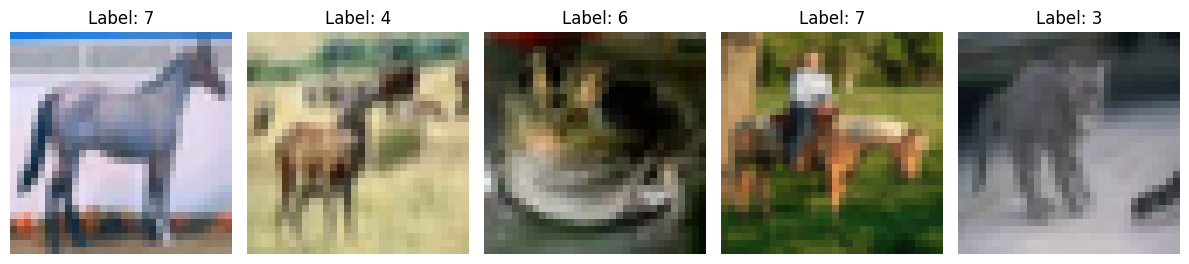

Number of Classes: 10

MODEL ARCHITECTURE
DeepQNN(
  (classical): Sequential(
    (0): Linear(in_features=3072, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

Model Parameters
----------------------------
Total Parameters     : 821,986
Trainable Parameters : 821,986
Quantum Parameters   : 144
Number of Qubits     : 8
Quantum Layers       : 6
SIMAM Parameters     : 0

Starting Training...



Epoch 1/25 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [01/25] | Train Loss: 2.1243 | Train Acc: 16.85% | Val Loss: 2.0114 | Val Acc: 18.40%


Epoch 2/25 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

...

Epoch 25/25 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [25/25] | Train Loss: 1.0423 | Train Acc: 62.97% | Val Loss: 1.6607 | Val Acc: 46.56%


Testing:   0%|          | 0/157 [00:00<?, ?it/s]


Final Test Accuracy: 47.69%

Sample Prediction
-----------------
True Label     : 3
Predicted Label: 3


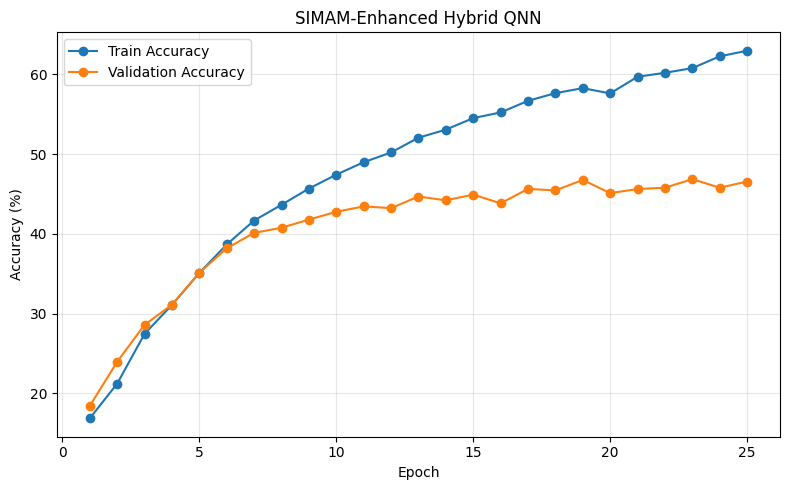

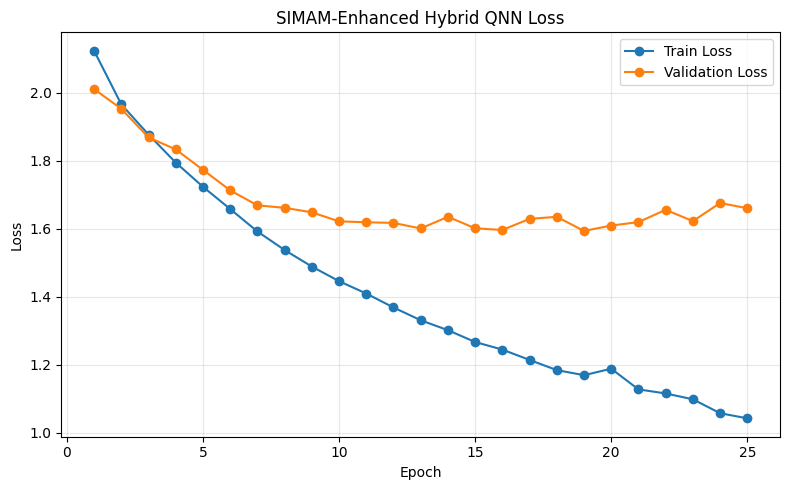

In [5]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 72

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using Seed: {SEED}")


# ============================================================
# Hyperparameters
# ============================================================

BATCH_SIZE = 64
EPOCHS = 25
LR = 0.001

NUM_QUBITS = 8
NUM_LAYERS = 6

SIMAM_E_LAMBDA = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")



# ============================================================
# Dataset
# ============================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    ),
])

full_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# Train / Validation Split
# ============================================================

val_fraction = 0.1

val_size = int(
    len(full_train_dataset) * val_fraction
)

train_size = (
    len(full_train_dataset) - val_size
)


train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Class Distribution
# ============================================================

# train_labels = full_train_dataset.targets.numpy()

# ============================================================
# Class Distribution
# ============================================================

train_labels = np.array(
    full_train_dataset.targets
)[train_dataset.indices]

test_labels = np.array(
    test_dataset.targets
)

print("\nTraining class distribution:")
print(Counter(train_labels))

print("\nTesting class distribution:")
print(Counter(test_labels))

# ============================================================
# Class Weights
# ============================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

print("\nClass Weights:")

for i, w in enumerate(class_weights):
    print(
        f"Class {i}: {w.item():.4f}"
    )


# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization for visualization
    mean = np.array(
        [0.4914, 0.4822, 0.4465]
    )
    
    std = np.array(
        [0.2470, 0.2435, 0.2616]
    )
    
    img = image.permute(
        1, 2, 0
    ).numpy()
    
    img = (
        img * std + mean
    )
    
    img = np.clip(
        img,
        0,
        1
    )
    
    ax.imshow(img)

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()

# ============================================================
# Number of Classes — Automatically Detected
# ============================================================
NUM_CLASSES = len(
    np.unique(
        np.array(full_train_dataset.targets)
    )
)
print(f"Number of Classes: {NUM_CLASSES}")


# ============================================================
# SIMAM
# Simple Attention Module
# ============================================================

class SIMAM(nn.Module):

    def __init__(
        self,
        e_lambda=1e-4
    ):

        super().__init__()

        self.e_lambda = e_lambda


    def forward(self, x):

        # ----------------------------------------------------
        # Expected input:
        #
        # x = [Batch, Channels, Height, Width]
        #
        # FashionMNIST:
        #
        # x = [B, 1, 28, 28]
        # ----------------------------------------------------

        b, c, h, w = x.size()


        # ----------------------------------------------------
        # Number of spatial locations minus one
        # ----------------------------------------------------

        n = h * w - 1


        # ----------------------------------------------------
        # Spatial mean
        # ----------------------------------------------------

        mean = x.mean(
            dim=(2, 3),
            keepdim=True
        )


        # ----------------------------------------------------
        # Squared deviation from mean
        # ----------------------------------------------------

        squared_diff = (
            x - mean
        ) ** 2


        # ----------------------------------------------------
        # Spatial variance
        # ----------------------------------------------------

        variance = (
            squared_diff.sum(
                dim=(2, 3),
                keepdim=True
            ) / n
        )


        # ----------------------------------------------------
        # SIMAM Energy
        # ----------------------------------------------------

        energy = (
            squared_diff
            /
            (
                4
                * (
                    variance
                    + self.e_lambda
                )
            )
        ) + 0.5


        # ----------------------------------------------------
        # Attention weights
        # ----------------------------------------------------

        attention = torch.sigmoid(
            1.0 / energy
        )


        # ----------------------------------------------------
        # Re-weight feature map
        # ----------------------------------------------------

        return x * attention


# ============================================================
# Quantum Device
# ============================================================

dev = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


# ============================================================
# Quantum Circuit
# ============================================================

@qml.qnode(
    dev,
    interface="torch",
    diff_method="backprop"
)

def quantum_circuit(
    inputs,
    weights
):

    # --------------------------------------------------------
    # Quantum Data Encoding
    # --------------------------------------------------------

    qml.AngleEmbedding(
        inputs,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Variational Quantum Circuit
    # --------------------------------------------------------

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Pauli-Z Measurements
    # --------------------------------------------------------

    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(NUM_QUBITS)
    ]


# ============================================================
# Quantum Parameter Shape
# ============================================================

weight_shapes = {

    "weights": (
        NUM_LAYERS,
        NUM_QUBITS,
        3
    )

}


# ============================================================
# Quantum Layer
# ============================================================

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)


# ============================================================
# Deep Hybrid QNN
# ============================================================

# class DeepQNN(nn.Module):

#     def __init__(self, num_classes):

#         super().__init__()


#         # ====================================================
#         # 1. SIMAM Attention
#         # ====================================================

#         self.simam = SIMAM(
#             e_lambda=SIMAM_E_LAMBDA
#         )


#         # ====================================================
#         # 2. Classical Feature Extractor
#         # ====================================================

#         self.classical = nn.Sequential(

#             # 784 → 256
#             # nn.Linear(
#             #     784,
#             #     256
#             # ),
#             nn.Linear(3072, 256),
#             nn.ReLU(),


#             # 256 → 128
#             nn.Linear(
#                 256,
#                 128
#             ),

#             nn.ReLU(),


        #     # 128 → NUM_QUBITS
        #     nn.Linear(
        #         128,
        #         NUM_QUBITS
        #     )

        # )


        # # ====================================================
        # # 3. Quantum Neural Network
        # # ====================================================

        # self.quantum = quantum_layer


        # # ====================================================
        # # 4. Classical Classifier
        # # ====================================================

        # self.classifier = nn.Sequential(

        #     # NUM_QUBITS → 64
        #     nn.Linear(
        #         NUM_QUBITS,
        #         64
        #     ),

        #     nn.ReLU(),


        #     # 64 → 10
        #     nn.Linear(
        #         64,
        #         num_classes
        #     )
        # )


    # # ========================================================
    # # Forward Pass
    # # ========================================================

    # def forward(self, x):


    #     # ====================================================
    #     # STEP 1 — Input
    #     # ====================================================
    #     #
    #     # x:
    #     #
    #     # [B, 1, 28, 28]
    #     #
    #     # ====================================================


    #     # ====================================================
    #     # STEP 2 — SIMAM
    #     # ====================================================

    #     x = self.simam(x)


    #     # ====================================================
    #     # STEP 3 — Flatten
    #     # ====================================================
    #     #
    #     # [B, 1, 28, 28]
    #     #
    #     #        ↓
    #     #
    #     # [B, 784]
    #     #
    #     # ====================================================

    #     x = x.flatten(
    #         start_dim=1
    #     )


        # # ====================================================
        # # STEP 4 — Classical Feature Extraction
        # # ====================================================
        # #
        # # 784 → 256 → 128 → NUM_QUBITS
        # #
        # # ====================================================

        # x = self.classical(x)


        # # ====================================================
        # # STEP 5 — Bound Quantum Angles
        # # ====================================================
        # #
        # # tanh:
        # #
        # # [-∞, +∞] → [-1, +1]
        # #
        # # × π:
        # #
        # # [-1, +1] → [-π, +π]
        # #
        # # ====================================================

        # x = torch.tanh(x) * np.pi


        # # ====================================================
        # # STEP 6 — Quantum Circuit
        # # ====================================================

        # quantum_device = x.device


        # # default.qubit runs on CPU
        # x = self.quantum(
        #     x.cpu()
        # )


        # # Move quantum output back
        # # to original device

        # x = x.to(
        #     quantum_device
        # )


        # # ====================================================
        # # STEP 7 — Classical Classifier
        # # ====================================================
        # #
        # # NUM_QUBITS → 64 → 10
        # #
        # # ====================================================

        # x = self.classifier(x)


        # return x

class DeepQNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        # ====================================================
        # 1. Classical Feature Extractor
        # ====================================================

        self.classical = nn.Sequential(

            # 3072 → 256
            nn.Linear(3072, 256),
            nn.ReLU(),

            # 256 → 128
            nn.Linear(256, 128),
            nn.ReLU(),

            # 128 → 8 qubits
            nn.Linear(128, NUM_QUBITS)
        )

        # ====================================================
        # 2. Quantum Neural Network
        # ====================================================

        self.quantum = quantum_layer

        # ====================================================
        # 3. Classical Classifier
        # ====================================================

        self.classifier = nn.Sequential(

            # 8 → 64
            nn.Linear(NUM_QUBITS, 64),
            nn.ReLU(),

            # 64 → 10
            nn.Linear(64, num_classes)
        )


    def forward(self, x):

            # ====================================================
            # STEP 1 — Flatten CIFAR-10 Image
            # ====================================================
            # [B, 3, 32, 32]
            #      ↓
            # [B, 3072]
            # ====================================================
        
            x = x.flatten(start_dim=1)
        
            # ====================================================
            # STEP 2 — Classical Feature Extraction
            # ====================================================
            # 3072 → 256 → 128 → 8
            # ====================================================
        
            x = self.classical(x)
        
            # ====================================================
            # STEP 3 — Bound Quantum Angles
            # ====================================================
        
            x = torch.tanh(x) * np.pi
        
            # ====================================================
            # STEP 4 — Quantum Circuit
            # ====================================================
        
            quantum_device = x.device
        
            x = self.quantum(x.cpu())
        
            # Move quantum output back
            x = x.to(quantum_device)
        
            # ====================================================
            # STEP 5 — Classical Classifier
            # ====================================================
            # 8 → 64 → 10
            # ====================================================
        
            x = self.classifier(x)
        
            return x

# ============================================================
# Create Model
# ============================================================

model = DeepQNN(
    num_classes=NUM_CLASSES
).to(DEVICE)


# ============================================================
# Model Summary
# ============================================================

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

print(model)


# ============================================================
# Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


print("\nModel Parameters")
print("----------------------------")

print(
    f"Total Parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params:,}"
)

print(
    f"Quantum Parameters   : "
    f"{quantum_params:,}"
)

print(
    f"Number of Qubits     : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum Layers       : "
    f"{NUM_LAYERS}"
)

print(
    f"SIMAM Parameters     : 0"
)

print("=" * 60)


# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# Training
# ============================================================

print("\nStarting Training...\n")


# ============================================================
# History
# ============================================================

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []


# ============================================================
# Epoch Loop
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()


    train_loss = 0.0

    train_correct = 0

    train_total = 0


    train_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Train]"
        ),
        leave=False
    )


    for step, (
        images,
        labels
    ) in enumerate(
        train_bar,
        start=1
    ):


        # ----------------------------------------------------
        # Move data to device
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # Update parameters
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Accumulate loss
        # ----------------------------------------------------

        train_loss += loss.item()


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        _, predicted = torch.max(
            outputs,
            1
        )


        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        train_bar.set_postfix(

            Loss=(
                f"{train_loss / step:.4f}"
            ),

            Acc=(
                f"{100 * train_correct / train_total:.2f}%"
            )

        )


    # ========================================================
    # Epoch Training Metrics
    # ========================================================

    train_loss /= len(
        train_loader
    )

    train_acc = (
        100
        * train_correct
        / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_loss = 0.0

    val_correct = 0

    val_total = 0


    val_bar = tqdm(
        val_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Val]"
        ),
        leave=False
    )


    with torch.no_grad():

        for step, (
            images,
            labels
        ) in enumerate(
            val_bar,
            start=1
        ):


            # ------------------------------------------------
            # Move data
            # ------------------------------------------------

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # Validation loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            val_loss += loss.item()


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            _, predicted = torch.max(
                outputs,
                1
            )


            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            # ------------------------------------------------
            # Progress bar
            # ------------------------------------------------

            val_bar.set_postfix(

                Loss=(
                    f"{val_loss / step:.4f}"
                ),

                Acc=(
                    f"{100 * val_correct / val_total:.2f}%"
                )

            )


    # ========================================================
    # Epoch Validation Metrics
    # ========================================================

    val_loss /= len(
        val_loader
    )

    val_acc = (
        100
        * val_correct
        / val_total
    )


    # ========================================================
    # Store History
    # ========================================================

    train_loss_history.append(
        train_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_loss_history.append(
        val_loss
    )

    val_acc_history.append(
        val_acc
    )


    # ========================================================
    # Epoch Summary
    # ========================================================

    print(

        f"Epoch "
        f"[{epoch + 1:02d}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Train Acc: "
        f"{train_acc:.2f}% | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val Acc: "
        f"{val_acc:.2f}%"

    )


# ============================================================
# FINAL TESTING
# ============================================================

model.eval()


correct = 0

total = 0


test_bar = tqdm(
    test_loader,
    desc="Testing"
)


with torch.no_grad():

    for images, labels in test_bar:


        # ----------------------------------------------------
        # Move data
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        _, predicted = outputs.max(
            1
        )


        # ----------------------------------------------------
        # Accuracy
        # ----------------------------------------------------

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


        test_bar.set_postfix({

            "Acc":
                f"{100 * correct / total:.2f}%"

        })


# ============================================================
# Final Test Accuracy
# ============================================================

final_test_accuracy = (
    100
    * correct
    / total
)


print(
    f"\nFinal Test Accuracy: "
    f"{final_test_accuracy:.2f}%"
)


# ============================================================
# Predict One Test Sample
# ============================================================

image, label = test_dataset[0]


model.eval()


with torch.no_grad():

    prediction = model(
        image.unsqueeze(0).to(
            DEVICE
        )
    )

    predicted = (
        prediction
        .argmax(dim=1)
        .item()
    )


print("\nSample Prediction")
print("-----------------")

print(
    "True Label     :",
    label
)

print(
    "Predicted Label:",
    predicted
)


# ============================================================
# Plot Training / Validation Accuracy
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_acc_history,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_acc_history,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "SIMAM-Enhanced Hybrid QNN"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_accuracy.png",
    dpi=150
)

plt.show()


# ============================================================
# Plot Training / Validation Loss
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_loss_history,
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_loss_history,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "SIMAM-Enhanced Hybrid QNN Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_loss.png",
    dpi=150
)

plt.show()

Using Seed: 2
Using device: cpu

Training class distribution:
Counter({np.int64(7): 4533, np.int64(8): 4514, np.int64(6): 4510, np.int64(4): 4507, np.int64(5): 4501, np.int64(9): 4498, np.int64(1): 4498, np.int64(2): 4492, np.int64(0): 4484, np.int64(3): 4463})

Testing class distribution:
Counter({np.int64(3): 1000, np.int64(8): 1000, np.int64(0): 1000, np.int64(6): 1000, np.int64(1): 1000, np.int64(9): 1000, np.int64(5): 1000, np.int64(7): 1000, np.int64(4): 1000, np.int64(2): 1000})

Class Weights:
Class 0: 1.0036
Class 1: 1.0004
Class 2: 1.0018
Class 3: 1.0083
Class 4: 0.9984
Class 5: 0.9998
Class 6: 0.9978
Class 7: 0.9927
Class 8: 0.9969
Class 9: 1.0004


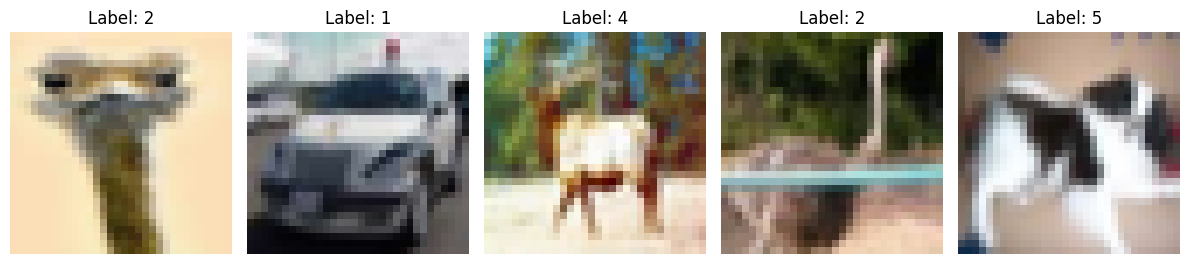

Number of Classes: 10

MODEL ARCHITECTURE
DeepQNN(
  (classical): Sequential(
    (0): Linear(in_features=3072, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

Model Parameters
----------------------------
Total Parameters     : 821,986
Trainable Parameters : 821,986
Quantum Parameters   : 144
Number of Qubits     : 8
Quantum Layers       : 6
SIMAM Parameters     : 0

Starting Training...



Epoch 1/25 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [01/25] | Train Loss: 2.3031 | Train Acc: 10.19% | Val Loss: 2.3033 | Val Acc: 9.78%


Epoch 2/25 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

...

Epoch 25/25 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [25/25] | Train Loss: 2.3028 | Train Acc: 9.92% | Val Loss: 2.3025 | Val Acc: 10.04%


Testing:   0%|          | 0/157 [00:00<?, ?it/s]


Final Test Accuracy: 10.00%

Sample Prediction
-----------------
True Label     : 3
Predicted Label: 1


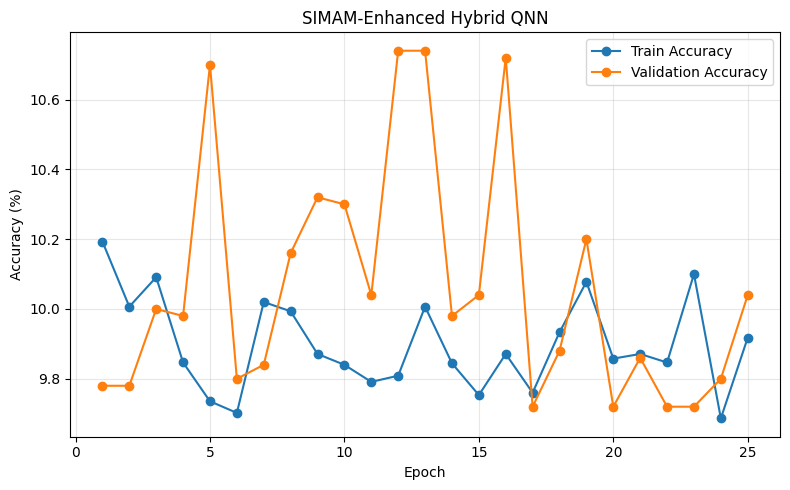

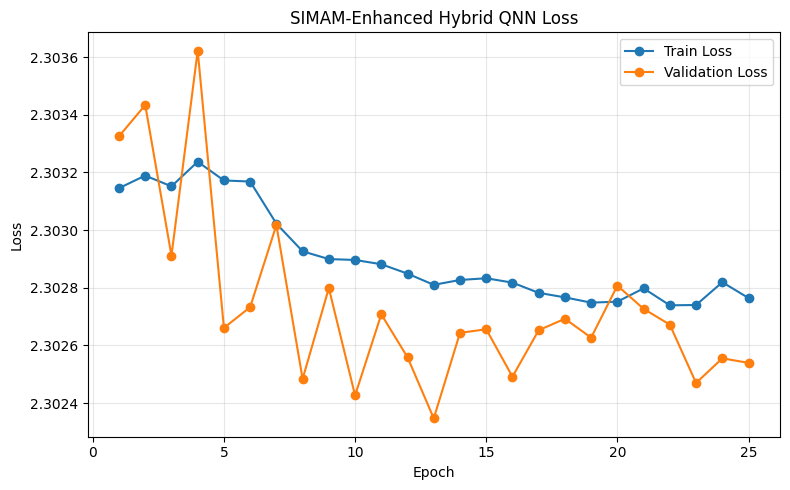

In [6]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 2

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using Seed: {SEED}")


# ============================================================
# Hyperparameters
# ============================================================

BATCH_SIZE = 64
EPOCHS = 25
LR = 0.001

NUM_QUBITS = 8
NUM_LAYERS = 6

SIMAM_E_LAMBDA = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")



# ============================================================
# Dataset
# ============================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    ),
])

full_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# Train / Validation Split
# ============================================================

val_fraction = 0.1

val_size = int(
    len(full_train_dataset) * val_fraction
)

train_size = (
    len(full_train_dataset) - val_size
)


train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Class Distribution
# ============================================================

# train_labels = full_train_dataset.targets.numpy()

# ============================================================
# Class Distribution
# ============================================================

train_labels = np.array(
    full_train_dataset.targets
)[train_dataset.indices]

test_labels = np.array(
    test_dataset.targets
)

print("\nTraining class distribution:")
print(Counter(train_labels))

print("\nTesting class distribution:")
print(Counter(test_labels))

# ============================================================
# Class Weights
# ============================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

print("\nClass Weights:")

for i, w in enumerate(class_weights):
    print(
        f"Class {i}: {w.item():.4f}"
    )


# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization for visualization
    mean = np.array(
        [0.4914, 0.4822, 0.4465]
    )
    
    std = np.array(
        [0.2470, 0.2435, 0.2616]
    )
    
    img = image.permute(
        1, 2, 0
    ).numpy()
    
    img = (
        img * std + mean
    )
    
    img = np.clip(
        img,
        0,
        1
    )
    
    ax.imshow(img)

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()

# ============================================================
# Number of Classes — Automatically Detected
# ============================================================
NUM_CLASSES = len(
    np.unique(
        np.array(full_train_dataset.targets)
    )
)
print(f"Number of Classes: {NUM_CLASSES}")


# ============================================================
# SIMAM
# Simple Attention Module
# ============================================================

class SIMAM(nn.Module):

    def __init__(
        self,
        e_lambda=1e-4
    ):

        super().__init__()

        self.e_lambda = e_lambda


    def forward(self, x):

        # ----------------------------------------------------
        # Expected input:
        #
        # x = [Batch, Channels, Height, Width]
        #
        # FashionMNIST:
        #
        # x = [B, 1, 28, 28]
        # ----------------------------------------------------

        b, c, h, w = x.size()


        # ----------------------------------------------------
        # Number of spatial locations minus one
        # ----------------------------------------------------

        n = h * w - 1


        # ----------------------------------------------------
        # Spatial mean
        # ----------------------------------------------------

        mean = x.mean(
            dim=(2, 3),
            keepdim=True
        )


        # ----------------------------------------------------
        # Squared deviation from mean
        # ----------------------------------------------------

        squared_diff = (
            x - mean
        ) ** 2


        # ----------------------------------------------------
        # Spatial variance
        # ----------------------------------------------------

        variance = (
            squared_diff.sum(
                dim=(2, 3),
                keepdim=True
            ) / n
        )


        # ----------------------------------------------------
        # SIMAM Energy
        # ----------------------------------------------------

        energy = (
            squared_diff
            /
            (
                4
                * (
                    variance
                    + self.e_lambda
                )
            )
        ) + 0.5


        # ----------------------------------------------------
        # Attention weights
        # ----------------------------------------------------

        attention = torch.sigmoid(
            1.0 / energy
        )


        # ----------------------------------------------------
        # Re-weight feature map
        # ----------------------------------------------------

        return x * attention


# ============================================================
# Quantum Device
# ============================================================

dev = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


# ============================================================
# Quantum Circuit
# ============================================================

@qml.qnode(
    dev,
    interface="torch",
    diff_method="backprop"
)

def quantum_circuit(
    inputs,
    weights
):

    # --------------------------------------------------------
    # Quantum Data Encoding
    # --------------------------------------------------------

    qml.AngleEmbedding(
        inputs,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Variational Quantum Circuit
    # --------------------------------------------------------

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Pauli-Z Measurements
    # --------------------------------------------------------

    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(NUM_QUBITS)
    ]


# ============================================================
# Quantum Parameter Shape
# ============================================================

weight_shapes = {

    "weights": (
        NUM_LAYERS,
        NUM_QUBITS,
        3
    )

}


# ============================================================
# Quantum Layer
# ============================================================

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)


# ============================================================
# Deep Hybrid QNN
# ============================================================

# class DeepQNN(nn.Module):

#     def __init__(self, num_classes):

#         super().__init__()


#         # ====================================================
#         # 1. SIMAM Attention
#         # ====================================================

#         self.simam = SIMAM(
#             e_lambda=SIMAM_E_LAMBDA
#         )


#         # ====================================================
#         # 2. Classical Feature Extractor
#         # ====================================================

#         self.classical = nn.Sequential(

#             # 784 → 256
#             # nn.Linear(
#             #     784,
#             #     256
#             # ),
#             nn.Linear(3072, 256),
#             nn.ReLU(),


#             # 256 → 128
#             nn.Linear(
#                 256,
#                 128
#             ),

#             nn.ReLU(),


        #     # 128 → NUM_QUBITS
        #     nn.Linear(
        #         128,
        #         NUM_QUBITS
        #     )

        # )


        # # ====================================================
        # # 3. Quantum Neural Network
        # # ====================================================

        # self.quantum = quantum_layer


        # # ====================================================
        # # 4. Classical Classifier
        # # ====================================================

        # self.classifier = nn.Sequential(

        #     # NUM_QUBITS → 64
        #     nn.Linear(
        #         NUM_QUBITS,
        #         64
        #     ),

        #     nn.ReLU(),


        #     # 64 → 10
        #     nn.Linear(
        #         64,
        #         num_classes
        #     )
        # )


    # # ========================================================
    # # Forward Pass
    # # ========================================================

    # def forward(self, x):


    #     # ====================================================
    #     # STEP 1 — Input
    #     # ====================================================
    #     #
    #     # x:
    #     #
    #     # [B, 1, 28, 28]
    #     #
    #     # ====================================================


    #     # ====================================================
    #     # STEP 2 — SIMAM
    #     # ====================================================

    #     x = self.simam(x)


    #     # ====================================================
    #     # STEP 3 — Flatten
    #     # ====================================================
    #     #
    #     # [B, 1, 28, 28]
    #     #
    #     #        ↓
    #     #
    #     # [B, 784]
    #     #
    #     # ====================================================

    #     x = x.flatten(
    #         start_dim=1
    #     )


        # # ====================================================
        # # STEP 4 — Classical Feature Extraction
        # # ====================================================
        # #
        # # 784 → 256 → 128 → NUM_QUBITS
        # #
        # # ====================================================

        # x = self.classical(x)


        # # ====================================================
        # # STEP 5 — Bound Quantum Angles
        # # ====================================================
        # #
        # # tanh:
        # #
        # # [-∞, +∞] → [-1, +1]
        # #
        # # × π:
        # #
        # # [-1, +1] → [-π, +π]
        # #
        # # ====================================================

        # x = torch.tanh(x) * np.pi


        # # ====================================================
        # # STEP 6 — Quantum Circuit
        # # ====================================================

        # quantum_device = x.device


        # # default.qubit runs on CPU
        # x = self.quantum(
        #     x.cpu()
        # )


        # # Move quantum output back
        # # to original device

        # x = x.to(
        #     quantum_device
        # )


        # # ====================================================
        # # STEP 7 — Classical Classifier
        # # ====================================================
        # #
        # # NUM_QUBITS → 64 → 10
        # #
        # # ====================================================

        # x = self.classifier(x)


        # return x

class DeepQNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        # ====================================================
        # 1. Classical Feature Extractor
        # ====================================================

        self.classical = nn.Sequential(

            # 3072 → 256
            nn.Linear(3072, 256),
            nn.ReLU(),

            # 256 → 128
            nn.Linear(256, 128),
            nn.ReLU(),

            # 128 → 8 qubits
            nn.Linear(128, NUM_QUBITS)
        )

        # ====================================================
        # 2. Quantum Neural Network
        # ====================================================

        self.quantum = quantum_layer

        # ====================================================
        # 3. Classical Classifier
        # ====================================================

        self.classifier = nn.Sequential(

            # 8 → 64
            nn.Linear(NUM_QUBITS, 64),
            nn.ReLU(),

            # 64 → 10
            nn.Linear(64, num_classes)
        )


    def forward(self, x):

            # ====================================================
            # STEP 1 — Flatten CIFAR-10 Image
            # ====================================================
            # [B, 3, 32, 32]
            #      ↓
            # [B, 3072]
            # ====================================================
        
            x = x.flatten(start_dim=1)
        
            # ====================================================
            # STEP 2 — Classical Feature Extraction
            # ====================================================
            # 3072 → 256 → 128 → 8
            # ====================================================
        
            x = self.classical(x)
        
            # ====================================================
            # STEP 3 — Bound Quantum Angles
            # ====================================================
        
            x = torch.tanh(x) * np.pi
        
            # ====================================================
            # STEP 4 — Quantum Circuit
            # ====================================================
        
            quantum_device = x.device
        
            x = self.quantum(x.cpu())
        
            # Move quantum output back
            x = x.to(quantum_device)
        
            # ====================================================
            # STEP 5 — Classical Classifier
            # ====================================================
            # 8 → 64 → 10
            # ====================================================
        
            x = self.classifier(x)
        
            return x

# ============================================================
# Create Model
# ============================================================

model = DeepQNN(
    num_classes=NUM_CLASSES
).to(DEVICE)


# ============================================================
# Model Summary
# ============================================================

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

print(model)


# ============================================================
# Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


print("\nModel Parameters")
print("----------------------------")

print(
    f"Total Parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params:,}"
)

print(
    f"Quantum Parameters   : "
    f"{quantum_params:,}"
)

print(
    f"Number of Qubits     : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum Layers       : "
    f"{NUM_LAYERS}"
)

print(
    f"SIMAM Parameters     : 0"
)

print("=" * 60)


# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# Training
# ============================================================

print("\nStarting Training...\n")


# ============================================================
# History
# ============================================================

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []


# ============================================================
# Epoch Loop
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()


    train_loss = 0.0

    train_correct = 0

    train_total = 0


    train_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Train]"
        ),
        leave=False
    )


    for step, (
        images,
        labels
    ) in enumerate(
        train_bar,
        start=1
    ):


        # ----------------------------------------------------
        # Move data to device
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # Update parameters
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Accumulate loss
        # ----------------------------------------------------

        train_loss += loss.item()


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        _, predicted = torch.max(
            outputs,
            1
        )


        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        train_bar.set_postfix(

            Loss=(
                f"{train_loss / step:.4f}"
            ),

            Acc=(
                f"{100 * train_correct / train_total:.2f}%"
            )

        )


    # ========================================================
    # Epoch Training Metrics
    # ========================================================

    train_loss /= len(
        train_loader
    )

    train_acc = (
        100
        * train_correct
        / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_loss = 0.0

    val_correct = 0

    val_total = 0


    val_bar = tqdm(
        val_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Val]"
        ),
        leave=False
    )


    with torch.no_grad():

        for step, (
            images,
            labels
        ) in enumerate(
            val_bar,
            start=1
        ):


            # ------------------------------------------------
            # Move data
            # ------------------------------------------------

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # Validation loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            val_loss += loss.item()


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            _, predicted = torch.max(
                outputs,
                1
            )


            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            # ------------------------------------------------
            # Progress bar
            # ------------------------------------------------

            val_bar.set_postfix(

                Loss=(
                    f"{val_loss / step:.4f}"
                ),

                Acc=(
                    f"{100 * val_correct / val_total:.2f}%"
                )

            )


    # ========================================================
    # Epoch Validation Metrics
    # ========================================================

    val_loss /= len(
        val_loader
    )

    val_acc = (
        100
        * val_correct
        / val_total
    )


    # ========================================================
    # Store History
    # ========================================================

    train_loss_history.append(
        train_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_loss_history.append(
        val_loss
    )

    val_acc_history.append(
        val_acc
    )


    # ========================================================
    # Epoch Summary
    # ========================================================

    print(

        f"Epoch "
        f"[{epoch + 1:02d}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Train Acc: "
        f"{train_acc:.2f}% | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val Acc: "
        f"{val_acc:.2f}%"

    )


# ============================================================
# FINAL TESTING
# ============================================================

model.eval()


correct = 0

total = 0


test_bar = tqdm(
    test_loader,
    desc="Testing"
)


with torch.no_grad():

    for images, labels in test_bar:


        # ----------------------------------------------------
        # Move data
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        _, predicted = outputs.max(
            1
        )


        # ----------------------------------------------------
        # Accuracy
        # ----------------------------------------------------

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


        test_bar.set_postfix({

            "Acc":
                f"{100 * correct / total:.2f}%"

        })


# ============================================================
# Final Test Accuracy
# ============================================================

final_test_accuracy = (
    100
    * correct
    / total
)


print(
    f"\nFinal Test Accuracy: "
    f"{final_test_accuracy:.2f}%"
)


# ============================================================
# Predict One Test Sample
# ============================================================

image, label = test_dataset[0]


model.eval()


with torch.no_grad():

    prediction = model(
        image.unsqueeze(0).to(
            DEVICE
        )
    )

    predicted = (
        prediction
        .argmax(dim=1)
        .item()
    )


print("\nSample Prediction")
print("-----------------")

print(
    "True Label     :",
    label
)

print(
    "Predicted Label:",
    predicted
)


# ============================================================
# Plot Training / Validation Accuracy
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_acc_history,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_acc_history,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "SIMAM-Enhanced Hybrid QNN"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_accuracy.png",
    dpi=150
)

plt.show()


# ============================================================
# Plot Training / Validation Loss
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_loss_history,
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_loss_history,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "SIMAM-Enhanced Hybrid QNN Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_loss.png",
    dpi=150
)

plt.show()

Using Seed: 7
Using device: cpu

Training class distribution:
Counter({np.int64(9): 4528, np.int64(8): 4524, np.int64(3): 4511, np.int64(7): 4510, np.int64(5): 4503, np.int64(0): 4502, np.int64(1): 4498, np.int64(6): 4483, np.int64(2): 4471, np.int64(4): 4470})

Testing class distribution:
Counter({np.int64(3): 1000, np.int64(8): 1000, np.int64(0): 1000, np.int64(6): 1000, np.int64(1): 1000, np.int64(9): 1000, np.int64(5): 1000, np.int64(7): 1000, np.int64(4): 1000, np.int64(2): 1000})

Class Weights:
Class 0: 0.9996
Class 1: 1.0004
Class 2: 1.0065
Class 3: 0.9976
Class 4: 1.0067
Class 5: 0.9993
Class 6: 1.0038
Class 7: 0.9978
Class 8: 0.9947
Class 9: 0.9938


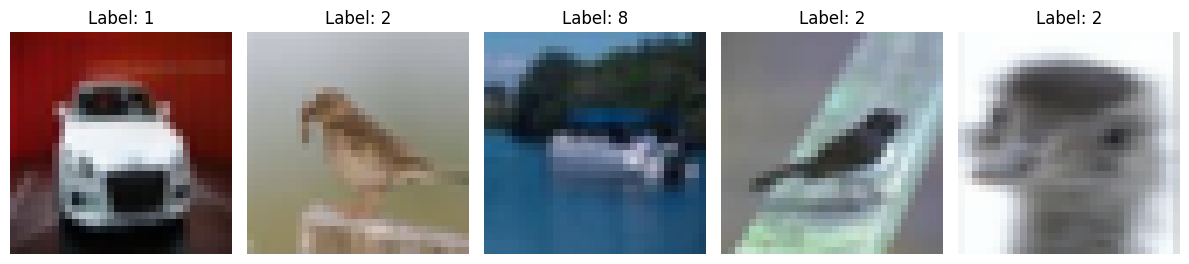

Number of Classes: 10

MODEL ARCHITECTURE
DeepQNN(
  (classical): Sequential(
    (0): Linear(in_features=3072, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

Model Parameters
----------------------------
Total Parameters     : 821,986
Trainable Parameters : 821,986
Quantum Parameters   : 144
Number of Qubits     : 8
Quantum Layers       : 6
SIMAM Parameters     : 0

Starting Training...



Epoch 1/25 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [01/25] | Train Loss: 2.2246 | Train Acc: 14.30% | Val Loss: 2.1146 | Val Acc: 17.66%


Epoch 2/25 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

...

Epoch 25/25 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [25/25] | Train Loss: 1.1104 | Train Acc: 59.67% | Val Loss: 1.6139 | Val Acc: 47.88%


Testing:   0%|          | 0/157 [00:00<?, ?it/s]


Final Test Accuracy: 47.60%

Sample Prediction
-----------------
True Label     : 3
Predicted Label: 5


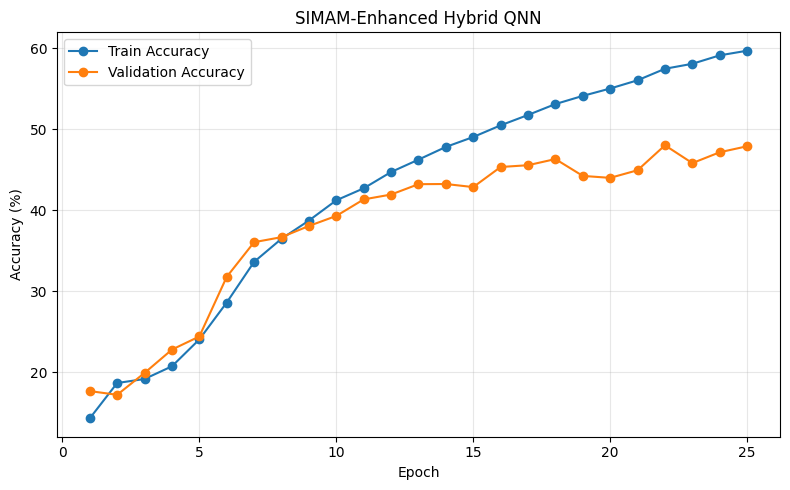

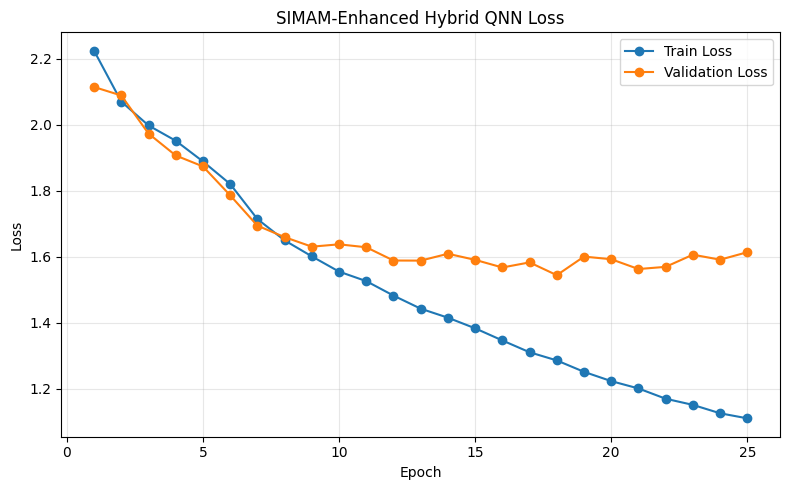

In [7]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 7

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using Seed: {SEED}")


# ============================================================
# Hyperparameters
# ============================================================

BATCH_SIZE = 64
EPOCHS = 25
LR = 0.001

NUM_QUBITS = 8
NUM_LAYERS = 6

SIMAM_E_LAMBDA = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")



# ============================================================
# Dataset
# ============================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    ),
])

full_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# Train / Validation Split
# ============================================================

val_fraction = 0.1

val_size = int(
    len(full_train_dataset) * val_fraction
)

train_size = (
    len(full_train_dataset) - val_size
)


train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Class Distribution
# ============================================================

# train_labels = full_train_dataset.targets.numpy()

# ============================================================
# Class Distribution
# ============================================================

train_labels = np.array(
    full_train_dataset.targets
)[train_dataset.indices]

test_labels = np.array(
    test_dataset.targets
)

print("\nTraining class distribution:")
print(Counter(train_labels))

print("\nTesting class distribution:")
print(Counter(test_labels))

# ============================================================
# Class Weights
# ============================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

print("\nClass Weights:")

for i, w in enumerate(class_weights):
    print(
        f"Class {i}: {w.item():.4f}"
    )


# ============================================================
# Plot 5 Random FashionMNIST Samples
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(12, 3)
)


sample_indices = np.random.choice(
    len(full_train_dataset),
    size=5,
    replace=False
)


for ax, idx in zip(
    axes,
    sample_indices
):

    image, label = full_train_dataset[idx]

    # Undo normalization for visualization
    mean = np.array(
        [0.4914, 0.4822, 0.4465]
    )
    
    std = np.array(
        [0.2470, 0.2435, 0.2616]
    )
    
    img = image.permute(
        1, 2, 0
    ).numpy()
    
    img = (
        img * std + mean
    )
    
    img = np.clip(
        img,
        0,
        1
    )
    
    ax.imshow(img)

    ax.set_title(
        f"Label: {label}"
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    "sample_images.png",
    dpi=150
)

plt.show()

# ============================================================
# Number of Classes — Automatically Detected
# ============================================================
NUM_CLASSES = len(
    np.unique(
        np.array(full_train_dataset.targets)
    )
)
print(f"Number of Classes: {NUM_CLASSES}")


# ============================================================
# SIMAM
# Simple Attention Module
# ============================================================

class SIMAM(nn.Module):

    def __init__(
        self,
        e_lambda=1e-4
    ):

        super().__init__()

        self.e_lambda = e_lambda


    def forward(self, x):

        # ----------------------------------------------------
        # Expected input:
        #
        # x = [Batch, Channels, Height, Width]
        #
        # FashionMNIST:
        #
        # x = [B, 1, 28, 28]
        # ----------------------------------------------------

        b, c, h, w = x.size()


        # ----------------------------------------------------
        # Number of spatial locations minus one
        # ----------------------------------------------------

        n = h * w - 1


        # ----------------------------------------------------
        # Spatial mean
        # ----------------------------------------------------

        mean = x.mean(
            dim=(2, 3),
            keepdim=True
        )


        # ----------------------------------------------------
        # Squared deviation from mean
        # ----------------------------------------------------

        squared_diff = (
            x - mean
        ) ** 2


        # ----------------------------------------------------
        # Spatial variance
        # ----------------------------------------------------

        variance = (
            squared_diff.sum(
                dim=(2, 3),
                keepdim=True
            ) / n
        )


        # ----------------------------------------------------
        # SIMAM Energy
        # ----------------------------------------------------

        energy = (
            squared_diff
            /
            (
                4
                * (
                    variance
                    + self.e_lambda
                )
            )
        ) + 0.5


        # ----------------------------------------------------
        # Attention weights
        # ----------------------------------------------------

        attention = torch.sigmoid(
            1.0 / energy
        )


        # ----------------------------------------------------
        # Re-weight feature map
        # ----------------------------------------------------

        return x * attention


# ============================================================
# Quantum Device
# ============================================================

dev = qml.device(
    "default.qubit",
    wires=NUM_QUBITS
)


# ============================================================
# Quantum Circuit
# ============================================================

@qml.qnode(
    dev,
    interface="torch",
    diff_method="backprop"
)

def quantum_circuit(
    inputs,
    weights
):

    # --------------------------------------------------------
    # Quantum Data Encoding
    # --------------------------------------------------------

    qml.AngleEmbedding(
        inputs,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Variational Quantum Circuit
    # --------------------------------------------------------

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(NUM_QUBITS)
    )


    # --------------------------------------------------------
    # Pauli-Z Measurements
    # --------------------------------------------------------

    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(NUM_QUBITS)
    ]


# ============================================================
# Quantum Parameter Shape
# ============================================================

weight_shapes = {

    "weights": (
        NUM_LAYERS,
        NUM_QUBITS,
        3
    )

}


# ============================================================
# Quantum Layer
# ============================================================

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)


# ============================================================
# Deep Hybrid QNN
# ============================================================

# class DeepQNN(nn.Module):

#     def __init__(self, num_classes):

#         super().__init__()


#         # ====================================================
#         # 1. SIMAM Attention
#         # ====================================================

#         self.simam = SIMAM(
#             e_lambda=SIMAM_E_LAMBDA
#         )


#         # ====================================================
#         # 2. Classical Feature Extractor
#         # ====================================================

#         self.classical = nn.Sequential(

#             # 784 → 256
#             # nn.Linear(
#             #     784,
#             #     256
#             # ),
#             nn.Linear(3072, 256),
#             nn.ReLU(),


#             # 256 → 128
#             nn.Linear(
#                 256,
#                 128
#             ),

#             nn.ReLU(),


        #     # 128 → NUM_QUBITS
        #     nn.Linear(
        #         128,
        #         NUM_QUBITS
        #     )

        # )


        # # ====================================================
        # # 3. Quantum Neural Network
        # # ====================================================

        # self.quantum = quantum_layer


        # # ====================================================
        # # 4. Classical Classifier
        # # ====================================================

        # self.classifier = nn.Sequential(

        #     # NUM_QUBITS → 64
        #     nn.Linear(
        #         NUM_QUBITS,
        #         64
        #     ),

        #     nn.ReLU(),


        #     # 64 → 10
        #     nn.Linear(
        #         64,
        #         num_classes
        #     )
        # )


    # # ========================================================
    # # Forward Pass
    # # ========================================================

    # def forward(self, x):


    #     # ====================================================
    #     # STEP 1 — Input
    #     # ====================================================
    #     #
    #     # x:
    #     #
    #     # [B, 1, 28, 28]
    #     #
    #     # ====================================================


    #     # ====================================================
    #     # STEP 2 — SIMAM
    #     # ====================================================

    #     x = self.simam(x)


    #     # ====================================================
    #     # STEP 3 — Flatten
    #     # ====================================================
    #     #
    #     # [B, 1, 28, 28]
    #     #
    #     #        ↓
    #     #
    #     # [B, 784]
    #     #
    #     # ====================================================

    #     x = x.flatten(
    #         start_dim=1
    #     )


        # # ====================================================
        # # STEP 4 — Classical Feature Extraction
        # # ====================================================
        # #
        # # 784 → 256 → 128 → NUM_QUBITS
        # #
        # # ====================================================

        # x = self.classical(x)


        # # ====================================================
        # # STEP 5 — Bound Quantum Angles
        # # ====================================================
        # #
        # # tanh:
        # #
        # # [-∞, +∞] → [-1, +1]
        # #
        # # × π:
        # #
        # # [-1, +1] → [-π, +π]
        # #
        # # ====================================================

        # x = torch.tanh(x) * np.pi


        # # ====================================================
        # # STEP 6 — Quantum Circuit
        # # ====================================================

        # quantum_device = x.device


        # # default.qubit runs on CPU
        # x = self.quantum(
        #     x.cpu()
        # )


        # # Move quantum output back
        # # to original device

        # x = x.to(
        #     quantum_device
        # )


        # # ====================================================
        # # STEP 7 — Classical Classifier
        # # ====================================================
        # #
        # # NUM_QUBITS → 64 → 10
        # #
        # # ====================================================

        # x = self.classifier(x)


        # return x

class DeepQNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        # ====================================================
        # 1. Classical Feature Extractor
        # ====================================================

        self.classical = nn.Sequential(

            # 3072 → 256
            nn.Linear(3072, 256),
            nn.ReLU(),

            # 256 → 128
            nn.Linear(256, 128),
            nn.ReLU(),

            # 128 → 8 qubits
            nn.Linear(128, NUM_QUBITS)
        )

        # ====================================================
        # 2. Quantum Neural Network
        # ====================================================

        self.quantum = quantum_layer

        # ====================================================
        # 3. Classical Classifier
        # ====================================================

        self.classifier = nn.Sequential(

            # 8 → 64
            nn.Linear(NUM_QUBITS, 64),
            nn.ReLU(),

            # 64 → 10
            nn.Linear(64, num_classes)
        )


    def forward(self, x):

            # ====================================================
            # STEP 1 — Flatten CIFAR-10 Image
            # ====================================================
            # [B, 3, 32, 32]
            #      ↓
            # [B, 3072]
            # ====================================================
        
            x = x.flatten(start_dim=1)
        
            # ====================================================
            # STEP 2 — Classical Feature Extraction
            # ====================================================
            # 3072 → 256 → 128 → 8
            # ====================================================
        
            x = self.classical(x)
        
            # ====================================================
            # STEP 3 — Bound Quantum Angles
            # ====================================================
        
            x = torch.tanh(x) * np.pi
        
            # ====================================================
            # STEP 4 — Quantum Circuit
            # ====================================================
        
            quantum_device = x.device
        
            x = self.quantum(x.cpu())
        
            # Move quantum output back
            x = x.to(quantum_device)
        
            # ====================================================
            # STEP 5 — Classical Classifier
            # ====================================================
            # 8 → 64 → 10
            # ====================================================
        
            x = self.classifier(x)
        
            return x

# ============================================================
# Create Model
# ============================================================

model = DeepQNN(
    num_classes=NUM_CLASSES
).to(DEVICE)


# ============================================================
# Model Summary
# ============================================================

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

print(model)


# ============================================================
# Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


quantum_params = (
    NUM_LAYERS
    * NUM_QUBITS
    * 3
)


print("\nModel Parameters")
print("----------------------------")

print(
    f"Total Parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters : "
    f"{trainable_params:,}"
)

print(
    f"Quantum Parameters   : "
    f"{quantum_params:,}"
)

print(
    f"Number of Qubits     : "
    f"{NUM_QUBITS}"
)

print(
    f"Quantum Layers       : "
    f"{NUM_LAYERS}"
)

print(
    f"SIMAM Parameters     : 0"
)

print("=" * 60)


# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# Optimizer
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# Training
# ============================================================

print("\nStarting Training...\n")


# ============================================================
# History
# ============================================================

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []


# ============================================================
# Epoch Loop
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()


    train_loss = 0.0

    train_correct = 0

    train_total = 0


    train_bar = tqdm(
        train_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Train]"
        ),
        leave=False
    )


    for step, (
        images,
        labels
    ) in enumerate(
        train_bar,
        start=1
    ):


        # ----------------------------------------------------
        # Move data to device
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # Update parameters
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Accumulate loss
        # ----------------------------------------------------

        train_loss += loss.item()


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        _, predicted = torch.max(
            outputs,
            1
        )


        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        train_bar.set_postfix(

            Loss=(
                f"{train_loss / step:.4f}"
            ),

            Acc=(
                f"{100 * train_correct / train_total:.2f}%"
            )

        )


    # ========================================================
    # Epoch Training Metrics
    # ========================================================

    train_loss /= len(
        train_loader
    )

    train_acc = (
        100
        * train_correct
        / train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_loss = 0.0

    val_correct = 0

    val_total = 0


    val_bar = tqdm(
        val_loader,
        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS} "
            f"[Val]"
        ),
        leave=False
    )


    with torch.no_grad():

        for step, (
            images,
            labels
        ) in enumerate(
            val_bar,
            start=1
        ):


            # ------------------------------------------------
            # Move data
            # ------------------------------------------------

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # Validation loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            val_loss += loss.item()


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            _, predicted = torch.max(
                outputs,
                1
            )


            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            # ------------------------------------------------
            # Progress bar
            # ------------------------------------------------

            val_bar.set_postfix(

                Loss=(
                    f"{val_loss / step:.4f}"
                ),

                Acc=(
                    f"{100 * val_correct / val_total:.2f}%"
                )

            )


    # ========================================================
    # Epoch Validation Metrics
    # ========================================================

    val_loss /= len(
        val_loader
    )

    val_acc = (
        100
        * val_correct
        / val_total
    )


    # ========================================================
    # Store History
    # ========================================================

    train_loss_history.append(
        train_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_loss_history.append(
        val_loss
    )

    val_acc_history.append(
        val_acc
    )


    # ========================================================
    # Epoch Summary
    # ========================================================

    print(

        f"Epoch "
        f"[{epoch + 1:02d}/{EPOCHS}] | "

        f"Train Loss: "
        f"{train_loss:.4f} | "

        f"Train Acc: "
        f"{train_acc:.2f}% | "

        f"Val Loss: "
        f"{val_loss:.4f} | "

        f"Val Acc: "
        f"{val_acc:.2f}%"

    )


# ============================================================
# FINAL TESTING
# ============================================================

model.eval()


correct = 0

total = 0


test_bar = tqdm(
    test_loader,
    desc="Testing"
)


with torch.no_grad():

    for images, labels in test_bar:


        # ----------------------------------------------------
        # Move data
        # ----------------------------------------------------

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        _, predicted = outputs.max(
            1
        )


        # ----------------------------------------------------
        # Accuracy
        # ----------------------------------------------------

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


        test_bar.set_postfix({

            "Acc":
                f"{100 * correct / total:.2f}%"

        })


# ============================================================
# Final Test Accuracy
# ============================================================

final_test_accuracy = (
    100
    * correct
    / total
)


print(
    f"\nFinal Test Accuracy: "
    f"{final_test_accuracy:.2f}%"
)


# ============================================================
# Predict One Test Sample
# ============================================================

image, label = test_dataset[0]


model.eval()


with torch.no_grad():

    prediction = model(
        image.unsqueeze(0).to(
            DEVICE
        )
    )

    predicted = (
        prediction
        .argmax(dim=1)
        .item()
    )


print("\nSample Prediction")
print("-----------------")

print(
    "True Label     :",
    label
)

print(
    "Predicted Label:",
    predicted
)


# ============================================================
# Plot Training / Validation Accuracy
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_acc_history,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_acc_history,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "SIMAM-Enhanced Hybrid QNN"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_accuracy.png",
    dpi=150
)

plt.show()


# ============================================================
# Plot Training / Validation Loss
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_loss_history,
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_loss_history,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "SIMAM-Enhanced Hybrid QNN Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "simam_hybrid_qnn_loss.png",
    dpi=150
)

plt.show()